# EDS 217 Final Project: "The Twos"

Members: Kelly Morgan, Oliver Witt, Natasha Clemencon

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7d_project_kickoff.html)

Date: 09/09/2026


## 1. Import Data


In [320]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

import requests

def extract_file_id(url):
    """Extract file id from Google Drive Sharing URL."""
    return url.split("/")[-2]

def df_from_gdrive_csv(url):
    """ Get the CSV file from a Google Drive Sharing URL."""
    file_id = extract_file_id(url)
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={"id": file_id}, stream=True)
    return pd.read_csv(response.raw)

# Example of how to use:
# Note: your sharing link will be different, but should look like this:
sharing_url = "https://drive.google.com/file/d/1Fnt_dR8Iwes_Fz72mVG_86c3ZUZobIX0/view?usp=sharing"
spotify = df_from_gdrive_csv(sharing_url)
spotify.head()

KeyboardInterrupt: 

In [ ]:
from matplotlib import colormaps

cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list

In [ ]:
# plot_color_gradients('Qualitative',
#                      ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'okabe_ito',
#                       'Dark2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20',
#                       'tab20b', 'tab20c'])
cmap = plt.colormaps["Set2"]
set2 = [cmap(i) for i in range(3)]


## 2. Explore Data


In [ ]:
spotify.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [ ]:
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       "Children's Music", 'Children’s Music', 'Rap', 'Indie',
       'Classical', 'Pop', 'Reggae', 'Reggaeton', 'Jazz', 'Rock', 'Ska',
       'Comedy', 'Soul', 'Soundtrack', 'World'], dtype=object)

In [ ]:
# also, we need to combine the two different spellings 
# of "children's music" first into one genre
spotify['genre'] = spotify['genre'].str.replace('Children’s', 'Childrens')
spotify['genre'] = spotify['genre'].str.replace("Children's", 'Childrens')
 
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       'Childrens Music', 'Rap', 'Indie', 'Classical', 'Pop', 'Reggae',
       'Reggaeton', 'Jazz', 'Rock', 'Ska', 'Comedy', 'Soul', 'Soundtrack',
       'World'], dtype=object)

In [ ]:
print(spotify.shape)
spotify.isnull().sum()

(232725, 18)


genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

## 3. Clean Data


In [ ]:
# Drop NAs
spotify = spotify.dropna()
print(spotify.shape, "<- one row dropped")
spotify.isnull().sum()

(232724, 18) <- one row dropped


genre               0
artist_name         0
track_name          0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [ ]:
# Filtering by desired genres: Pop, Rap, Classical, and Opera
spotify_filtered = spotify[spotify['genre'].isin(['Pop', 'Rap', 'Classical', 'Opera'])]
print(spotify_filtered.shape)
spotify_filtered['genre'].unique()

(36154, 18)


array(['Opera', 'Rap', 'Classical', 'Pop'], dtype=object)

In [ ]:
# Remove duplicates-- there's a lot!
spotify_filtered = spotify_filtered.drop_duplicates(subset=['artist_name', 'track_name'])
print(spotify_filtered.shape)
print(36154-32438,"rows dropped")

(32438, 18)
3716 rows dropped


In [ ]:
# Create dataframe for each genre
opera = spotify_filtered[spotify_filtered['genre']== 'Opera']
classical = spotify_filtered[spotify_filtered['genre']== 'Classical']
pop = spotify_filtered[spotify_filtered['genre']== 'Pop']
rap = spotify_filtered[spotify_filtered['genre']== 'Rap']
spotify_filtered.shape

(32438, 18)

## Three Questions

### What is the difference in tempo across our genres of interest: Pop, Rap, Classical, and Opera?

In [ ]:
#Look at the mean tempos for each of the four genres, and sort them
#to see which genres have a higher mean tempo
opera['tempo'].mean()
classical['tempo'].mean()
rap['tempo'].mean()
pop['tempo'].mean()

spotify_filtered.groupby('genre')['tempo'].mean().sort_values(ascending=False)

genre
Rap          121.168351
Pop          120.943577
Classical    104.506744
Opera        101.802977
Name: tempo, dtype: float64

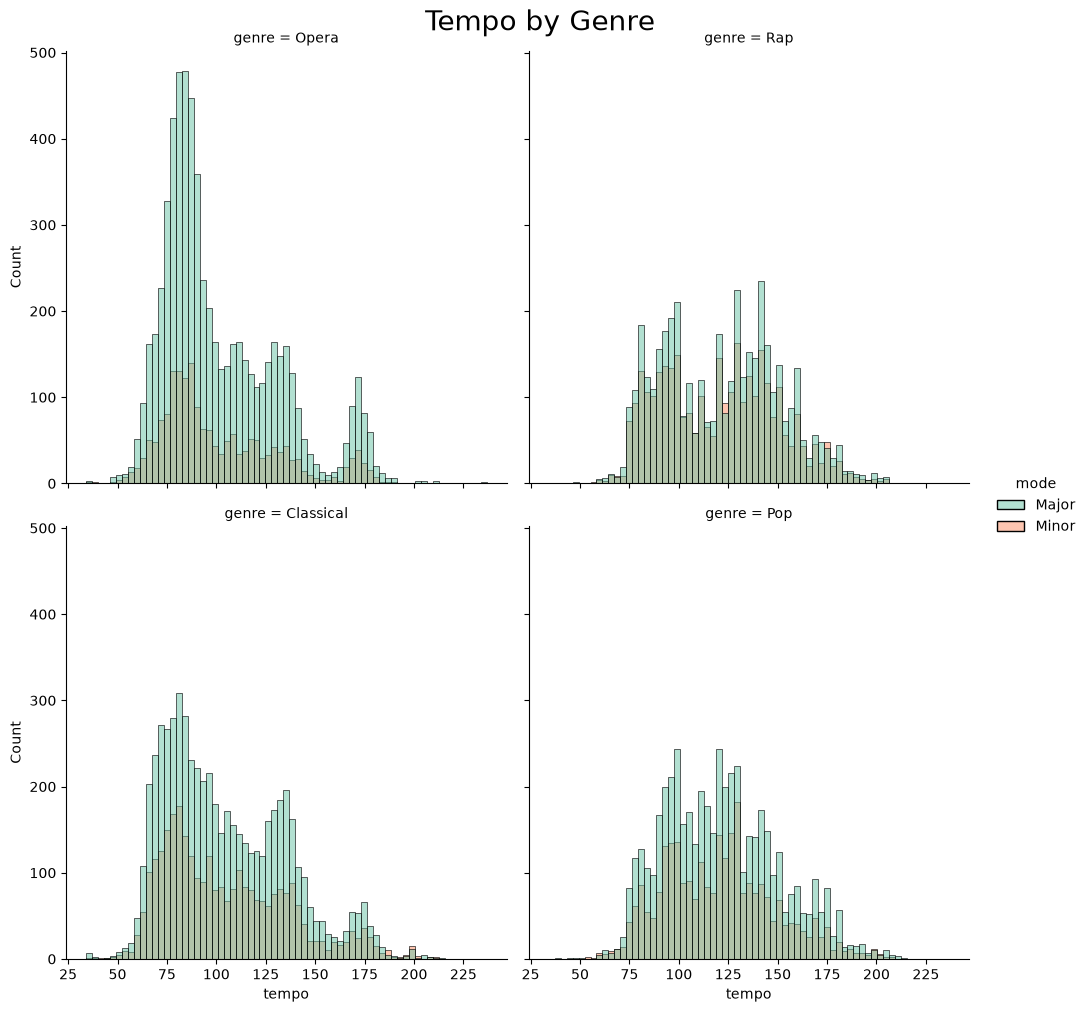

In [ ]:
#Graph the tempos for each of the four genres 
graph = sns.displot(
    spotify_filtered,
    x="tempo",
    col="genre",
    hue="mode",
    palette='Set2',
    col_wrap=2,
    facet_kws=dict(margin_titles=True),
)
graph.fig.suptitle("Tempo by Genre", ha='center', va='bottom', fontsize= 20, )
plt.show()

## How does song length vary across genre? How does this effect popularity? 

In [ ]:
# which genre has longer songs?
grouped = spotify_filtered.groupby('genre')['duration_ms'].agg(['mean', 'max', 'min', 'count'])
filtered_df = grouped.reset_index()
filtered_df

,genre,mean,max,min,count
0,Classical,312186.848731,3391040,15509,8865
1,Opera,259161.092271,2404810,30707,8280
2,Pop,219796.129315,645876,21547,7764
3,Rap,218186.691194,760973,39640,7529


In [ ]:
# how many rows does each of these have? 
# (i.e. how many songs does each genre have?)

print(f"there are {len(classical)} classical songs")
print(f"there are {len(opera)} opera songs")
print(f"there are {len(pop)} pop songs")
print(f"there are {len(rap)} rap songs")

there are 8865 classical songs
there are 8280 opera songs
there are 7764 pop songs
there are 7529 rap songs


In [ ]:
# filter for songs above a certain threshold
# lets say a "long" song is over eight minutes
# 8 minutes is 480,000 milliseconds

# then calculate proportion of songs of a
# certain genre that are "long"


long_classical = classical[classical['duration_ms'] > 480000]
print(f"there are {len(long_classical)} long classical songs")
percent_classical = ((len(long_classical)) / (len(classical))) * 100
print(f"{round(percent_classical, 2)}% of classical songs are long")

print(" ")

long_opera = opera[opera['duration_ms'] > 480000]
print(f"there are {len(long_opera)} long opera songs")
percent_opera = ((len(long_opera)) / (len(opera))) * 100
print(f"{round(percent_opera, 2)}% of opera songs are long")

print(" ")

long_pop = pop[pop['duration_ms'] > 480000]
print(f"there are {len(long_pop)} long pop songs")
percent_pop = ((len(long_pop)) / (len(pop))) * 100
print(f"{round(percent_pop, 2)}% of pop songs are long")

print(" ")

long_rap = rap[rap['duration_ms'] > 480000]
print(f"there are {len(long_rap)} long rap songs")
percent_rap = ((len(long_rap)) / (len(rap))) * 100
print(f"{round(percent_rap, 2)}% of rap songs are long")

there are 1305 long classical songs
14.72% of classical songs are long
 
there are 633 long opera songs
7.64% of opera songs are long
 
there are 11 long pop songs
0.14% of pop songs are long
 
there are 18 long rap songs
0.24% of rap songs are long


In [ ]:
# create and apply function to classify songs as
# long/normal/short

def islong(d):
    if d > 480000:
        return "> 8 min"
    elif d < 180000:
        return "< 3 min"
    else:
        return "3-8 min"

spotify_filtered['is long?'] = spotify_filtered['duration_ms'].apply(islong)

# gives a warning message but works!

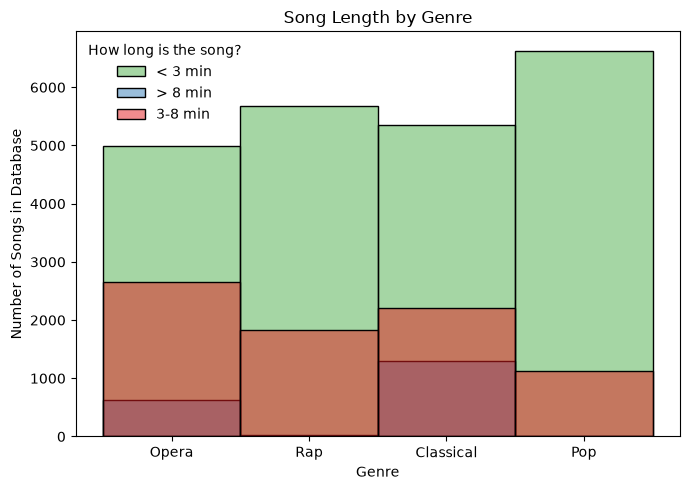

In [323]:
# Plot relative counts of
# song length cateogires for
#  our three selected genres
plt.figure(figsize=(7, 5))
sns.histplot(data=spotify_filtered, x='genre', hue='is long?', palette='Set1')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.legend(
    spotify_filtered['is long?'], 
    title= "How long is the song?", 
    loc= 'upper left',
    frameon=False
    )
plt.title("Song Length by Genre")
plt.tight_layout()
plt.show()

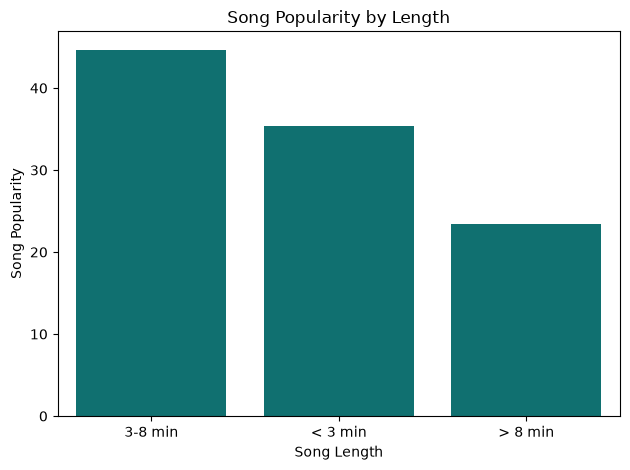

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [324]:
# compare popularity of long vs not long songs
# within these three selected genres

song_long = spotify_filtered.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=song_long, x='is long?', y='popularity', color='teal')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.title("Song Popularity by Length")
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

## Same figures with the WHOLE database (all genres)

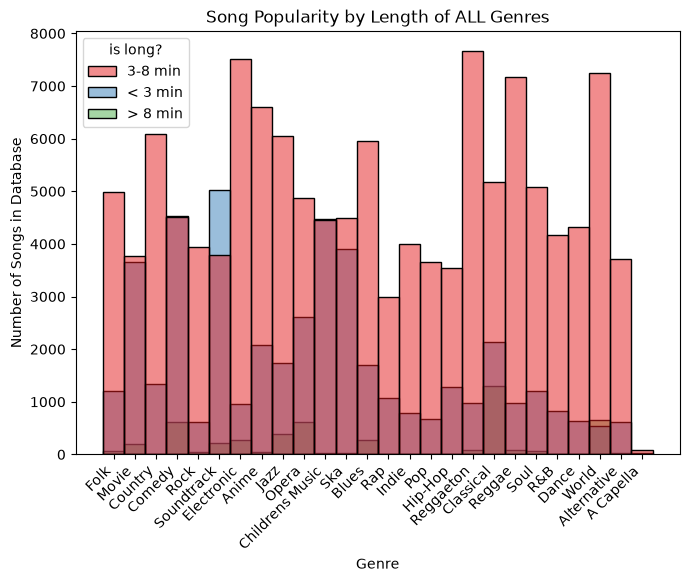

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [325]:
#go back and look at the WHOLE database:

#### Drop dubplicates for whole dataset
spotify = spotify.sample(frac=1).drop_duplicates(subset=['artist_name', 'track_name'])


spotify['is long?'] = spotify['duration_ms'].apply(islong)


plt.figure(figsize=(7, 5))
sns.histplot(data=spotify, x='genre', hue='is long?', palette='Set1')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.title("Song Popularity by Length of ALL Genres")
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

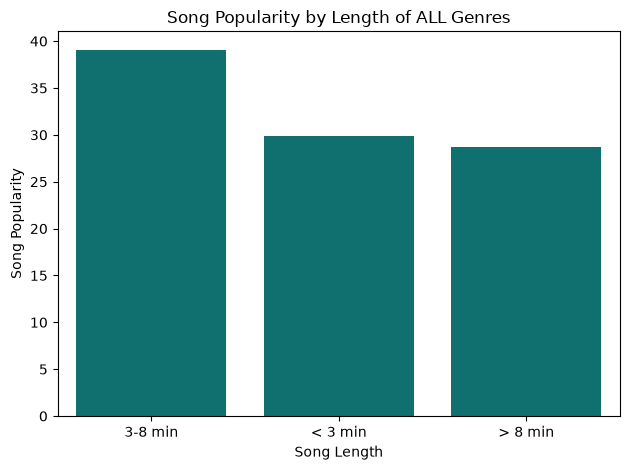

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [326]:
all_song_long = spotify.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=all_song_long, x='is long?', y='popularity', color='teal')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.title("Song Popularity by Length of ALL Genres")
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

## What is the most common key across all genres of music? How do the most common keys differ between our genres of interest?

### Filter Data:


In [327]:
### key distribution across ALL genres ###

# keep columns genre and key
keep_cols = ['genre', 'key']

# filter dataframe and group by key, aggregate by count
all_genres = spotify[keep_cols].groupby(['key'])['key'].count()

# reset the index and give the aggregation a column name, then sort by descending
all_genres_key = all_genres.reset_index(name='count').sort_values(['count'], ascending=False)

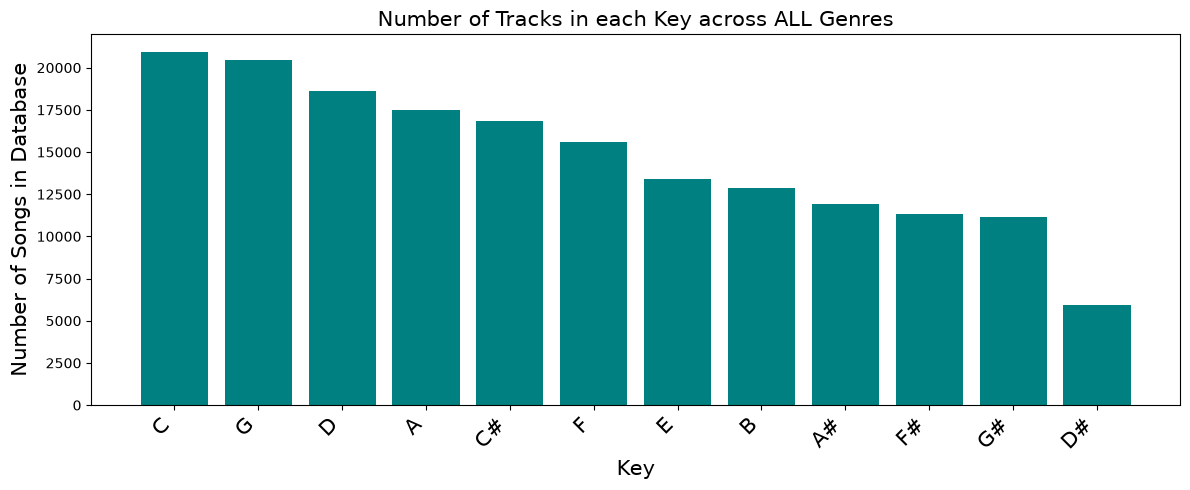

In [328]:
### Plot Number of Tracks in each Key across ALL Genres ###

plt.figure(figsize= (12, 5)) # 15 inch wide, 3 inch tall
plt.xticks(rotation=45, ha='right', fontsize=15)

plt.bar(all_genres_key['key'], all_genres_key['count'], color='teal')
plt.title("Number of Tracks in each Key across ALL Genres", fontsize=15)
plt.xlabel('Key', fontsize=15)
plt.ylabel('Number of Songs in Database', fontsize=15)

plt.tight_layout()

plt.show()

### Group, Aggregate, and Sort Data:



In [329]:
### key distribution across four desired genres ###

# Use spotify_filtered to groupby genre and key
genre_grouped = spotify_filtered[keep_cols].groupby(['genre', 'key'])['key'].count()
# reset.index() and rename cols
genre_grouped = genre_grouped.reset_index(name='count')
genre_grouped.head(12) # 12 keys

,genre,key,count
0,Classical,A,828
1,Classical,A#,626
2,Classical,B,417
3,Classical,C,1065
4,Classical,C#,695
5,Classical,D,1065
6,Classical,D#,563
7,Classical,E,763
8,Classical,F,864
9,Classical,F#,436


### Transform, Join, and Reshape Data:


In [330]:
# pivot table 
keys_pivot = genre_grouped.pivot_table(
    index='genre',
    columns='key',
    values='count'
)
keys_pivot

key,A,A#,B,C,C#,D,D#,E,F,F#,G,G#
genre,,,,,,,,,,,,
Classical,828.0,626.0,417.0,1065.0,695.0,1065.0,563.0,763.0,864.0,436.0,1096.0,447.0
Opera,665.0,656.0,381.0,919.0,649.0,908.0,598.0,705.0,913.0,382.0,862.0,642.0
Pop,630.0,531.0,662.0,896.0,912.0,704.0,258.0,537.0,693.0,583.0,750.0,608.0
Rap,572.0,576.0,658.0,717.0,1346.0,624.0,171.0,411.0,593.0,550.0,648.0,663.0


### Visualize Data

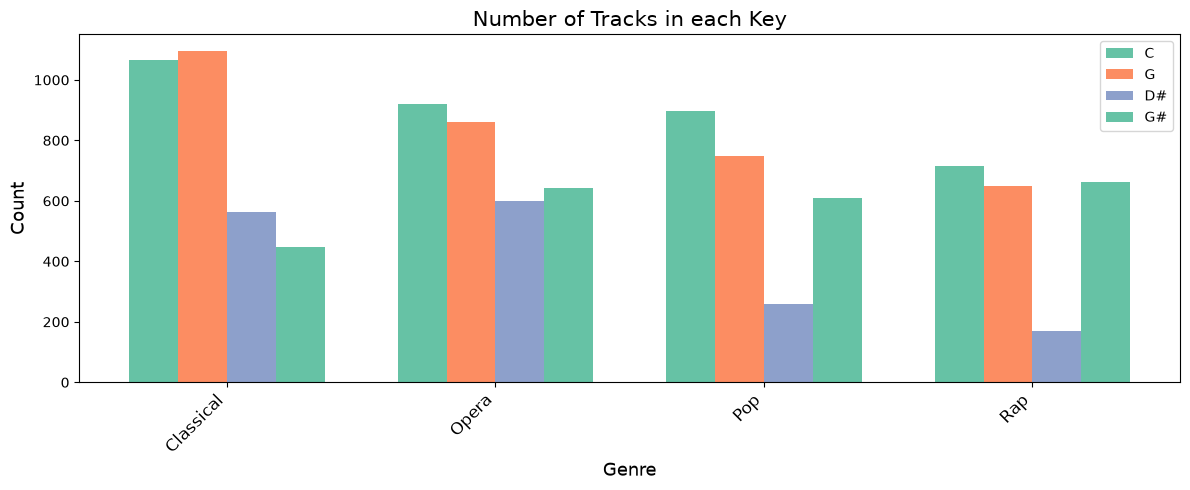

In [331]:
# Genres : Pop, Rap, Classical, Opera
# Keys: 'C', 'G', 'D#', 'G#'

keys = ['C', 'G', 'D#', 'G#']
pick_keys = keys_pivot[keys]

plt.figure(figsize= (12, 5)) # 15 inch wide, 3 inch tall
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.grouped_bar(
    pick_keys.to_numpy(), 
    tick_labels=pick_keys.index, 
    labels=pick_keys.columns,
    colors=set2
)
plt.title("Number of Tracks in each Key", fontsize=15)
plt.xlabel('Genre', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.legend()

plt.tight_layout()
plt.show()